# **Introduction to Image Processing**
## **Practical Work No. 2**
---

**Student:** Ibrahim Ege Bilgic

**Student ID No.:** 231ADB284

**Link to the programming code:** https://github.com/ibrahimegebilgic/practical2-imageprocessing

**Variant:** 4 (Logarithmic correction, Histogram linear correction (min-max))

---


In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files


### Upload 3 color images
- Underexposed (dark)
- Overexposed (bright)
- Grayish (low contrast)

After upload, rename the files on your computer so their names include one of these keywords: `under`, `over`, `gray`.


In [2]:
uploaded = files.upload()
paths = list(uploaded.keys())
paths


Saving alpine-hare-edwin-godinho.webp to alpine-hare-edwin-godinho.webp


['alpine-hare-edwin-godinho.webp']

In [3]:
def to_rgb_uint8(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if rgb.dtype != np.uint8:
        rgb = np.clip(rgb, 0, 255).astype(np.uint8)
    return rgb

def log_correction_rgb(img_rgb, a=12.0):
    x = img_rgb.astype(np.float32) / 255.0
    y = np.empty_like(x)
    denom = np.log(1.0 + a)
    y[..., 0] = np.log(1.0 + a * x[..., 0]) / denom
    y[..., 1] = np.log(1.0 + a * x[..., 1]) / denom
    y[..., 2] = np.log(1.0 + a * x[..., 2]) / denom
    return np.clip(y * 255.0, 0, 255).astype(np.uint8)

def minmax_linear_rgb(img_rgb):
    x = img_rgb.astype(np.float32)
    y = np.empty_like(x)
    for c in range(3):
        ch = x[..., c]
        mn = float(np.min(ch))
        mx = float(np.max(ch))
        if mx == mn:
            y[..., c] = ch
        else:
            y[..., c] = (ch - mn) * (255.0 / (mx - mn))
    return np.clip(y, 0, 255).astype(np.uint8)


In [4]:
def plot_rgb_hist(ax, img_rgb, title):
    ax.set_title(title)
    ax.set_xlim(0, 255)
    for i, col in enumerate(["r", "g", "b"]):
        h = cv2.calcHist([img_rgb], [i], None, [256], [0, 256]).ravel()
        ax.plot(h, color=col)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Count")

def show_results(name, orig, out1, out2):
    plt.figure(figsize=(15, 10))
    plt.suptitle(name, fontsize=16)
    ax1 = plt.subplot(3, 3, 1)
    ax1.imshow(orig)
    ax1.set_title("Original")
    ax1.axis("off")
    ax2 = plt.subplot(3, 3, 2)
    ax2.imshow(out1)
    ax2.set_title("Logarithmic correction")
    ax2.axis("off")
    ax3 = plt.subplot(3, 3, 3)
    ax3.imshow(out2)
    ax3.set_title("Histogram linear (min-max)")
    ax3.axis("off")
    ax4 = plt.subplot(3, 3, 4)
    plot_rgb_hist(ax4, orig, "Histogram: Original")
    ax5 = plt.subplot(3, 3, 5)
    plot_rgb_hist(ax5, out1, "Histogram: Logarithmic")
    ax6 = plt.subplot(3, 3, 6)
    plot_rgb_hist(ax6, out2, "Histogram: Min-max")
    plt.tight_layout()
    plt.show()


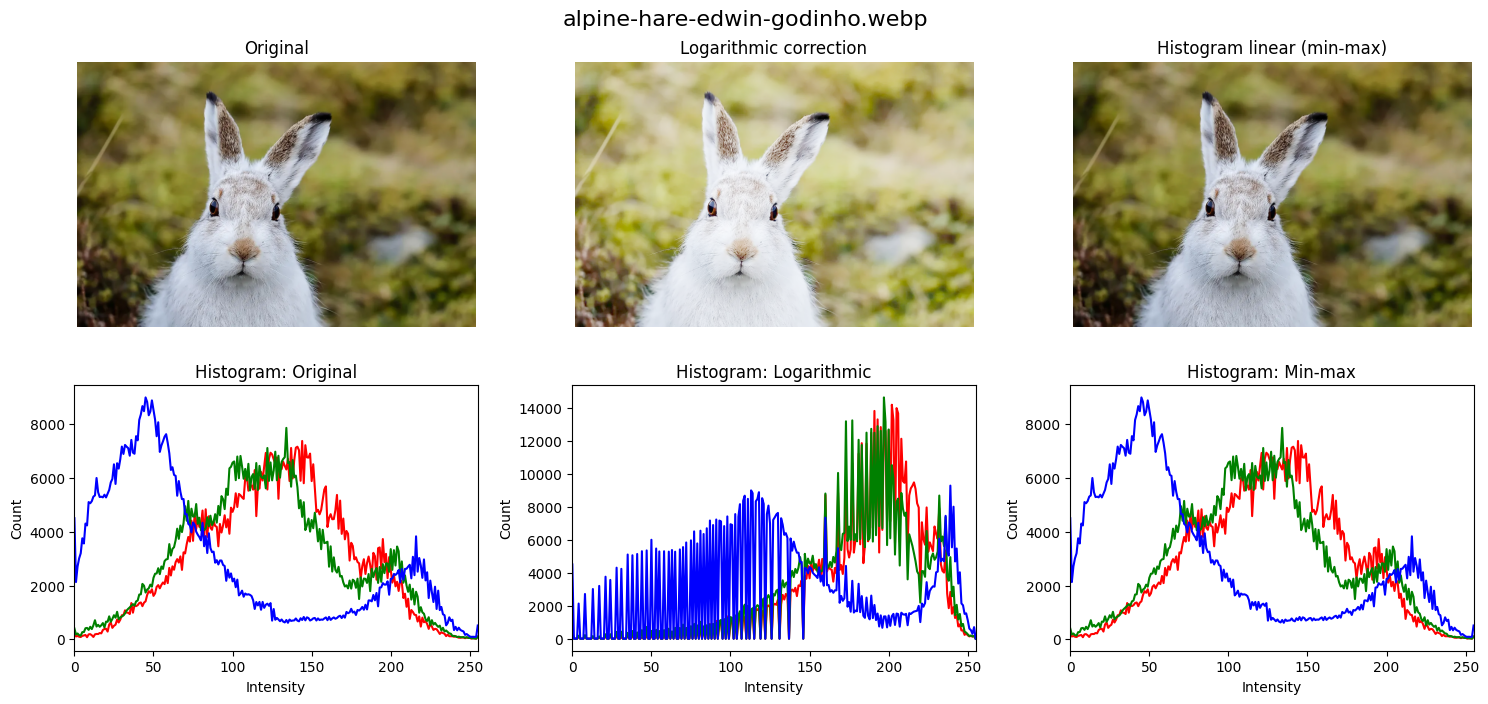

In [5]:
LOG_A = 12.0

def label_from_name(fname):
    f = fname.lower()
    if "under" in f:
        return "Underexposed"
    if "over" in f:
        return "Overexposed"
    if "gray" in f or "grey" in f or "low" in f:
        return "Grayish (low contrast)"
    return fname

for p in paths:
    bgr = cv2.imread(p)
    if bgr is None:
        print("Could not read:", p)
        continue
    orig = to_rgb_uint8(bgr)
    out_log = log_correction_rgb(orig, a=LOG_A)
    out_mm = minmax_linear_rgb(orig)
    show_results(label_from_name(p), orig, out_log, out_mm)


In [6]:
out_dir = "pw2_outputs"
os.makedirs(out_dir, exist_ok=True)

for p in paths:
    bgr = cv2.imread(p)
    if bgr is None:
        continue
    orig = to_rgb_uint8(bgr)
    out_log = log_correction_rgb(orig, a=LOG_A)
    out_mm = minmax_linear_rgb(orig)
    base = os.path.splitext(os.path.basename(p))[0]
    cv2.imwrite(os.path.join(out_dir, base + "_log.png"), cv2.cvtColor(out_log, cv2.COLOR_RGB2BGR))
    cv2.imwrite(os.path.join(out_dir, base + "_minmax.png"), cv2.cvtColor(out_mm, cv2.COLOR_RGB2BGR))

sorted(os.listdir(out_dir))


['alpine-hare-edwin-godinho_log.png', 'alpine-hare-edwin-godinho_minmax.png']

In [7]:
!pip install nbconvert


In [11]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/Practical_2.ipynb" \
  --to html \
  --embed-images


[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Practical_2.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 979392 bytes to /content/drive/MyDrive/Colab Notebooks/Practical_2.html


In [13]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/Practical_2.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Comparison**

Logarithmic correction makes dark parts brighter. It helps a lot when the image is too dark. The shadows become clearer and you can see more details. The histogram also moves to the right, mainly in the low values. Min–max correction is different. It stretches the values from the lowest to the highest. So the contrast becomes stronger in the whole image. The histogram becomes wider and fills more of the 0–255 range.

For the underexposed image, I think logarithmic correction keeps details better. It opens the shadows and does not make everything too harsh. Min–max can make some areas too black, so small details can disappear. For the low-contrast gray image, min–max works better. It makes the image look sharper and more clear. Log correction improves it, but not as much. For the overexposed image, both methods are limited. Very bright parts already lost information, so the details cannot really come back.

Log correction is good because it is simple and looks natural. It is very useful for dark images. But it can also show more noise in shadow areas. Min–max is good because it increases contrast a lot and uses the full range. It is great for flat images. But sometimes it looks too strong, and it can lose details in extreme dark or bright parts.


# **Conclusions**

In this practical work, I improved three different images using logarithmic correction and histogram linear correction (min–max). Logarithmic correction made the dark (underexposed) image brighter and revealed more details in the shadows.
However, it can also increase noise in very dark areas. Min–max correction increased the contrast strongly because it stretches pixel values to the full range (0–255). For the grayish (low contrast) image, min–max worked very well and the picture looked clearer. For the overexposed image, both methods had limits, because bright areas were already clipped and lost information. From the histograms, I saw that min–max spreads the values more, while log correction changes mainly the darker part of the histogram. Overall, I would choose log correction for underexposed images and min–max for low-contrast gray images, but I must be careful with overexposed photos.
